# 🔮 Notebook 05 — Predicciones y Análisis de Horizontes

**Tesis:** Modelo de Redes Neuronales para Predecir Consumo de Combustible Automotriz  
**Autor:** Eduardo Javier Oña Chiriboga — PUCE Ambato  

---

## 📋 Tabla de Contenidos

1. [Instalación de dependencias](#1)
2. [Detección de entorno y carga del modelo ganador](#2)
3. [Predicciones en conjunto de test](#3)
4. [Predicción iterativa a 30 días futuros](#4)
5. [Intervalos de confianza ±1std](#5)
6. [Agrupaciones: semanal, mensual y anual](#6)
7. [Análisis por horizontes (1, 7, 14, 30 días)](#7)
8. [Gráficas de predicciones futuras](#8)
9. [Guardado de todos los CSV](#9)
10. [Verificación final](#10)

---
> **Prerrequisito:** Haber ejecutado los Notebooks 03 y 04 completamente  
> **Este es el último notebook del pipeline**

## 1. Instalación de dependencias <a id='1'></a>

In [1]:
import subprocess, sys

REQUERIDOS = [
    ('tensorflow', 'tensorflow'),
    ('scikit-learn', 'sklearn'),
    ('pandas', 'pandas'),
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('seaborn', 'seaborn'),
    ('joblib', 'joblib'),
]

for pkg, imp in REQUERIDOS:
    try:
        __import__(imp)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  Instalado: {pkg}')

print('✅ Dependencias verificadas')


✅ Dependencias verificadas


## 2. Detección de entorno y carga del modelo ganador <a id='2'></a>

In [2]:
import os, sys, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

# ── Reproducibilidad ────────────────────────────────────────────────────────
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ── Parámetros globales ──────────────────────────────────────────────────────
WINDOW_SIZE = 30
HORIZON     = 1
PRODUCTOS   = ['extra', 'super', 'diesel']
N_DIAS_FUTURO = 30
N_DIAS_ANUAL  = 365

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
COLORES = {'extra': '#2196F3', 'super': '#4CAF50', 'diesel': '#FF5722'}

# ── Detección de entorno ─────────────────────────────────────────────────────
def detectar_entorno():
    try:
        import google.colab
        EN_COLAB = True
    except ImportError:
        EN_COLAB = False

    if EN_COLAB:
        print('📍 Entorno: Google Colab')
        if not os.path.exists('/content/Redes_Neuronales_completo'):
            subprocess.run(
                ['git', 'clone',
                 'https://github.com/Javier-Eduardo/Redes_Neuronales_completo.git',
                 '/content/Redes_Neuronales_completo'],
                check=True
            )
        BASE = '/content/Redes_Neuronales_completo'
    else:
        print('📍 Entorno: Local (VS Code)')
        candidatos = [os.getcwd(), os.path.dirname(os.path.abspath('__file__'))]
        BASE = None
        for c in candidatos:
            if os.path.exists(os.path.join(c, 'dataset_crudo.csv')):
                BASE = c
                break
        if BASE is None:
            raise FileNotFoundError(
                '❌ No se encontró dataset_crudo.csv. Abre VS Code en la carpeta raíz.'
            )

    PATHS = {
        'base':      BASE,
        'data':      os.path.join(BASE, 'data'),
        'modelos':   os.path.join(BASE, 'modelos'),
        'graf_eval': os.path.join(BASE, 'graficos', 'evaluacion'),
        'graf_pred': os.path.join(BASE, 'graficos', 'predicciones'),
    }
    for k in ['data', 'modelos', 'graf_eval', 'graf_pred']:
        os.makedirs(PATHS[k], exist_ok=True)
    return PATHS, EN_COLAB

PATHS, EN_COLAB = detectar_entorno()

# ── Verificar que existen archivos de los notebooks anteriores ─────────────
archivos_necesarios = [
    'modelo_final_nn.h5', 'modelo_ganador.txt',
    'scaler_extra.pkl', 'scaler_super.pkl', 'scaler_diesel.pkl',
    'fechas_test.npy',
    'X_test_extra_nn.npy', 'X_test_super_nn.npy', 'X_test_diesel_nn.npy',
    'dataset_limpio.csv',
]

faltantes = []
for f in archivos_necesarios:
    carpeta = PATHS['modelos'] if f.endswith('.h5') else PATHS['data']
    if not os.path.exists(os.path.join(carpeta, f)):
        faltantes.append(f)

if faltantes:
    raise FileNotFoundError(
        f'❌ Faltan archivos: {faltantes}\n'
        '   Ejecuta los Notebooks 03 y 04 primero.'
    )
print('✅ Todos los archivos previos disponibles')

📍 Entorno: Local (VS Code)
✅ Todos los archivos previos disponibles


In [3]:
# ── Leer modelo ganador ──────────────────────────────────────────────────
with open(os.path.join(PATHS['data'], 'modelo_ganador.txt')) as f:
    MODELO_GANADOR = f.read().strip()
print(f'🏆 Modelo ganador: {MODELO_GANADOR}')

# ── Cargar scalers ────────────────────────────────────────────────────────
scalers = {}
for p in PRODUCTOS:
    scalers[p] = joblib.load(os.path.join(PATHS['data'], f'scaler_{p}.pkl'))
scalers['multi'] = (
    joblib.load(os.path.join(PATHS['data'], 'scaler_multi.pkl'))
    if os.path.exists(os.path.join(PATHS['data'], 'scaler_multi.pkl'))
    else None
)
print('✅ Scalers cargados')

# ── Cargar datos de test ───────────────────────────────────────────────────
fechas_test = np.load(os.path.join(PATHS['data'], 'fechas_test.npy'), allow_pickle=True)
fechas_test = pd.to_datetime(fechas_test)
print(f'✅ fechas_test: {len(fechas_test)} fechas — {fechas_test[0].date()} → {fechas_test[-1].date()}')

test_data = {}
for p in PRODUCTOS:
    test_data[p] = {
        'X_test': np.load(os.path.join(PATHS['data'], f'X_test_{p}_nn.npy')),
        'y_test': np.load(os.path.join(PATHS['data'], f'y_test_{p}_nn.npy')),
    }
test_data['multi'] = {
    'X_test': np.load(os.path.join(PATHS['data'], 'X_test_multi_nn.npy')),
    'y_test': np.load(os.path.join(PATHS['data'], 'y_test_multi_nn.npy')),
}

# ── Cargar dataset_limpio para la ventana final ────────────────────────────
df_limpio = pd.read_csv(
    os.path.join(PATHS['data'], 'dataset_limpio.csv'),
    parse_dates=['fecha']
)
print(f'✅ dataset_limpio: {len(df_limpio)} días')

# ── Cargar los modelos entrenados ─────────────────────────────────────────
MAPA_MODELOS = {
    'LSTM':       'modelo_lstm_{p}.h5',
    'BiLSTM':     'modelo_bilstm_{p}.h5',
    'CNN-LSTM':   'modelo_cnn_lstm_{p}.h5',
    'LSTM-Multi': 'modelo_lstm_multi_global.h5',
}

models_ganador = {}
if MODELO_GANADOR == 'LSTM-Multi':
    models_ganador['multi'] = keras.models.load_model(
        os.path.join(PATHS['modelos'], 'modelo_lstm_multi_global.h5')
    )
    print(f'✅ Modelo multivariante cargado')
else:
    patron = MAPA_MODELOS[MODELO_GANADOR]
    for p in PRODUCTOS:
        nombre_h5 = patron.replace('{p}', p)
        models_ganador[p] = keras.models.load_model(
            os.path.join(PATHS['modelos'], nombre_h5)
        )
        print(f'  ✅ {nombre_h5} cargado')

print('\n✅ Todo listo para predicciones')

🏆 Modelo ganador: BiLSTM
✅ Scalers cargados
✅ fechas_test: 206 fechas — 2025-04-26 → 2025-11-17
✅ dataset_limpio: 1364 días

  ✅ modelo_bilstm_extra.h5 cargado
  ✅ modelo_bilstm_super.h5 cargado
  ✅ modelo_bilstm_diesel.h5 cargado

✅ Todo listo para predicciones


## 3. Predicciones en conjunto de test <a id='3'></a>

In [4]:
# ── Función de desescalado ────────────────────────────────────────────────
def desescalar(y_scaled, scaler, col_idx=0):
    y_scaled = np.array(y_scaled).flatten()
    if hasattr(scaler, 'n_features_in_') and scaler.n_features_in_ > 1:
        dummy = np.zeros((len(y_scaled), scaler.n_features_in_))
        dummy[:, col_idx] = y_scaled
        return scaler.inverse_transform(dummy)[:, col_idx]
    return scaler.inverse_transform(y_scaled.reshape(-1, 1)).flatten()

# ── Generar predicciones en test ──────────────────────────────────────────
pred_test_real  = {}  # predicciones desescaladas
true_test_real  = {}  # reales desescaladas
residuos_test   = {}  # para calcular std (intervalos de confianza)

if MODELO_GANADOR == 'LSTM-Multi':
    m = models_ganador['multi']
    y_pred_sc   = m.predict(test_data['multi']['X_test'], verbose=0)    # (n, 3)
    y_true_r    = scalers['multi'].inverse_transform(test_data['multi']['y_test'])  # (n, 3)
    y_pred_r    = scalers['multi'].inverse_transform(y_pred_sc)
    for i, p in enumerate(PRODUCTOS):
        true_test_real[p] = y_true_r[:, i]
        pred_test_real[p] = y_pred_r[:, i]
        residuos_test[p]  = true_test_real[p] - pred_test_real[p]
else:
    for i, p in enumerate(PRODUCTOS):
        m = models_ganador[p]
        y_pred_sc = m.predict(test_data[p]['X_test'], verbose=0).flatten()
        true_test_real[p] = desescalar(test_data[p]['y_test'], scalers[p])
        pred_test_real[p] = desescalar(y_pred_sc, scalers[p])
        residuos_test[p]  = true_test_real[p] - pred_test_real[p]

# Ajustar fechas: el test tiene WINDOW_SIZE días de desfase en el array
# Las fechas ya están ajustadas desde el Notebook 03
# Alinear longitudes
n_test_pred = len(pred_test_real['extra'])
fechas_test_alineadas = fechas_test[-n_test_pred:] if len(fechas_test) >= n_test_pred else fechas_test

# Si hay desfase, usar las últimas n_test_pred fechas del test
print(f'Días en test (predicciones): {n_test_pred}')
print(f'Fechas de test disponibles:  {len(fechas_test)}')

# ── Construir DataFrame predicciones_test_diarias ────────────────────────
n_comun = min(n_test_pred, len(fechas_test_alineadas))

df_pred_test = pd.DataFrame({
    'fecha':       fechas_test_alineadas[:n_comun],
    'extra_real':  np.round(true_test_real['extra'][:n_comun], 4),
    'super_real':  np.round(true_test_real['super'][:n_comun], 4),
    'diesel_real': np.round(true_test_real['diesel'][:n_comun], 4),
    'extra_pred':  np.round(pred_test_real['extra'][:n_comun], 4),
    'super_pred':  np.round(pred_test_real['super'][:n_comun], 4),
    'diesel_pred': np.round(pred_test_real['diesel'][:n_comun], 4),
})

print(f'\n✅ predicciones_test_diarias construido: {len(df_pred_test)} filas')
display(df_pred_test.head(5))

Días en test (predicciones): 206
Fechas de test disponibles:  206

✅ predicciones_test_diarias construido: 206 filas


,fecha,extra_real,super_real,diesel_real,extra_pred,super_pred,diesel_pred
0,2025-04-26,671.479980,44.851002,1361.512085,613.059692,47.509399,1362.374268
1,2025-04-27,523.187012,29.400000,480.045013,618.422913,47.325600,846.833679
2,2025-04-28,596.479004,62.486000,1459.708008,607.325378,46.554699,1627.447876
3,2025-04-29,691.942017,43.028999,2024.095947,605.783386,46.847599,1992.498657
4,2025-04-30,668.177002,53.685001,1609.499023,620.832581,46.627899,1952.980225


## 4. Predicción iterativa a 30 días futuros <a id='4'></a>

In [5]:
# ── Función de predicción iterativa ──────────────────────────────────────
def prediccion_iterativa(model, ultima_secuencia, n_pasos, scaler,
                          n_features=1, col_idx=0):
    """
    Predice n_pasos días hacia el futuro usando el modelo entrenado.
    ultima_secuencia: array (1, WINDOW_SIZE, n_features)
    Devuelve array desescalado de shape (n_pasos,) [univariante]
             o (n_pasos, n_features) [multivariante]
    """
    predicciones_sc = []
    seq = ultima_secuencia.copy().astype(np.float32)  # (1, WINDOW_SIZE, n_features)

    for step in range(n_pasos):
        pred = model.predict(seq, verbose=0)  # (1, n_outputs)
        predicciones_sc.append(pred[0])
        # Deslizar la ventana: descartar el primero, añadir la predicción al final
        seq = np.roll(seq, -1, axis=1)
        if n_features == 1:
            seq[0, -1, 0] = float(pred[0, 0])
        else:
            seq[0, -1, :] = pred[0, :]

    predicciones_sc = np.array(predicciones_sc)  # (n_pasos, n_outputs)

    # Desescalar
    if n_features == 1 or predicciones_sc.shape[1] == 1:
        dummy = np.zeros((len(predicciones_sc), scaler.n_features_in_
                          if hasattr(scaler, 'n_features_in_') else 1))
        dummy[:, col_idx] = predicciones_sc.flatten()
        return scaler.inverse_transform(dummy)[:, col_idx]
    else:
        return scaler.inverse_transform(predicciones_sc)

# ── Obtener la última ventana de datos reales para iniciar la predicción ──
# Escalar los últimos WINDOW_SIZE días del dataset completo
ultimos_dias = df_limpio.iloc[-WINDOW_SIZE:][PRODUCTOS].values  # (WINDOW_SIZE, 3)

print(f'Último día del dataset:   {df_limpio["fecha"].iloc[-1].date()}')
print(f'Inicio de predicciones:   {(df_limpio["fecha"].iloc[-1] + pd.Timedelta(days=1)).date()}')

# ── Fechas futuras ────────────────────────────────────────────────────────
fecha_inicio_pred = df_limpio['fecha'].iloc[-1] + pd.Timedelta(days=1)
fechas_futuras_30 = pd.date_range(
    start=fecha_inicio_pred, periods=N_DIAS_FUTURO, freq='D'
)
fechas_futuras_anual = pd.date_range(
    start=fecha_inicio_pred, periods=N_DIAS_ANUAL, freq='D'
)

# ── Predicciones a 30 días ────────────────────────────────────────────────
pred_futuras_30 = {}  # {producto: array (30,)}

if MODELO_GANADOR == 'LSTM-Multi':
    m = models_ganador['multi']
    # Escalar la ventana con el scaler multivariante
    ventana_sc = scalers['multi'].transform(ultimos_dias)  # (30, 3)
    seq_ini = ventana_sc[np.newaxis, :, :]                 # (1, 30, 3)
    pred_multi_r = prediccion_iterativa(
        m, seq_ini, N_DIAS_FUTURO, scalers['multi'], n_features=3
    )  # (30, 3)
    for i, p in enumerate(PRODUCTOS):
        pred_futuras_30[p] = pred_multi_r[:, i]
else:
    for i, p in enumerate(PRODUCTOS):
        m = models_ganador[p]
        ventana_vals = ultimos_dias[:, i].reshape(-1, 1)  # (30, 1)
        ventana_sc   = scalers[p].transform(ventana_vals)  # (30, 1)
        seq_ini = ventana_sc[np.newaxis, :, :]             # (1, 30, 1)
        pred_futuras_30[p] = prediccion_iterativa(
            m, seq_ini, N_DIAS_FUTURO, scalers[p], n_features=1
        )  # (30,)

print(f'\nPredicciones a {N_DIAS_FUTURO} días:')
for p in PRODUCTOS:
    print(f'  {p:8s}: min={pred_futuras_30[p].min():.1f}  max={pred_futuras_30[p].max():.1f}  '
          f'media={pred_futuras_30[p].mean():.1f}')

Último día del dataset:   2025-11-17
Inicio de predicciones:   2025-11-18

Predicciones a 30 días:
  extra   : min=587.0  max=618.7  media=606.7
  super   : min=59.6  max=74.8  media=66.8
  diesel  : min=919.3  max=2013.9  media=1573.1


## 5. Intervalos de confianza ±1std <a id='5'></a>

In [6]:
# ── Calcular std de residuos en test como proxy de incertidumbre ──────────
# El intervalo ±1std captura aprox. 68% de los errores
std_residuos = {}
for p in PRODUCTOS:
    std_residuos[p] = float(np.std(residuos_test[p]))
    print(f'  {p:8s}: std_residuos = {std_residuos[p]:.2f} galones')

# ── Construcción del DataFrame con intervalos ─────────────────────────────
df_pred_30 = pd.DataFrame({'fecha': fechas_futuras_30})
df_pred_30_ci = pd.DataFrame({'fecha': fechas_futuras_30})

for p in PRODUCTOS:
    # Clamp a 0 (no puede haber volumen negativo)
    pred = np.maximum(pred_futuras_30[p], 0)
    std  = std_residuos[p]
    df_pred_30[f'{p}_pred']   = np.round(pred, 4)
    df_pred_30_ci[f'{p}_pred']  = np.round(pred, 4)
    df_pred_30_ci[f'{p}_lower'] = np.round(np.maximum(pred - std, 0), 4)
    df_pred_30_ci[f'{p}_upper'] = np.round(pred + std, 4)

print('\n✅ Intervalos de confianza calculados')
display(df_pred_30_ci.head(5))

  extra   : std_residuos = 109.56 galones
  super   : std_residuos = 27.97 galones
  diesel  : std_residuos = 400.18 galones

✅ Intervalos de confianza calculados


,fecha,extra_pred,extra_lower,extra_upper,super_pred,super_lower,super_upper,diesel_pred,diesel_lower,diesel_upper
0,2025-11-18,592.2500,482.6899,701.8101,74.7641,46.7921,102.7361,1842.6902,1442.5120,2242.8684
1,2025-11-19,593.8100,484.2499,703.3701,73.7576,45.7856,101.7296,1829.4754,1429.2972,2229.6536
2,2025-11-20,594.5118,484.9517,704.0719,72.7463,44.7743,100.7183,1781.7783,1381.6001,2181.9565
3,2025-11-21,596.5541,486.9940,706.1142,71.8957,43.9237,99.8677,1655.8659,1255.6878,2056.0441
4,2025-11-22,596.6243,487.0642,706.1844,71.0648,43.0928,99.0368,1399.7567,999.5786,1799.9349


## 6. Agrupaciones: semanal, mensual y anual <a id='6'></a>

In [7]:
# ── predicciones_semanales.csv ────────────────────────────────────────────
df_semanal = df_pred_30.copy()
df_semanal['semana_inicio'] = df_semanal['fecha'].dt.to_period('W').apply(lambda r: r.start_time)
cols_pred = [f'{p}_pred' for p in PRODUCTOS]
df_pred_semanales = df_semanal.groupby('semana_inicio')[cols_pred].sum().reset_index()
df_pred_semanales.columns = ['semana_inicio'] + [f'{p}_pred' for p in PRODUCTOS]

print('Predicciones semanales:')
display(df_pred_semanales)

# ── predicciones_mensuales.csv ────────────────────────────────────────────
df_mensual = df_pred_30.copy()
df_mensual['mes'] = df_mensual['fecha'].dt.to_period('M').astype(str)
df_pred_mensuales = df_mensual.groupby('mes')[cols_pred].sum().reset_index()

print('\nPredicciones mensuales:')
display(df_pred_mensuales)

# ── predicciones_anuales.csv (proyección recursiva de 365 días) ───────────
print('\nGenerando proyección anual (365 días) — puede tardar varios minutos...')

pred_futuras_anual = {}

if MODELO_GANADOR == 'LSTM-Multi':
    m = models_ganador['multi']
    ventana_sc = scalers['multi'].transform(ultimos_dias)
    seq_ini = ventana_sc[np.newaxis, :, :]
    pred_anual_r = prediccion_iterativa(
        m, seq_ini, N_DIAS_ANUAL, scalers['multi'], n_features=3
    )
    for i, p in enumerate(PRODUCTOS):
        pred_futuras_anual[p] = np.maximum(pred_anual_r[:, i], 0)
else:
    for i, p in enumerate(PRODUCTOS):
        m = models_ganador[p]
        ventana_sc = scalers[p].transform(ultimos_dias[:, i].reshape(-1, 1))
        seq_ini = ventana_sc[np.newaxis, :, :]
        pred_futuras_anual[p] = np.maximum(
            prediccion_iterativa(m, seq_ini, N_DIAS_ANUAL, scalers[p]), 0
        )

df_pred_365 = pd.DataFrame({'fecha': fechas_futuras_anual})
for p in PRODUCTOS:
    df_pred_365[f'{p}_pred'] = np.round(pred_futuras_anual[p], 4)

# Agrupar por año
df_pred_365['año'] = df_pred_365['fecha'].dt.year
df_pred_anuales = df_pred_365.groupby('año')[[f'{p}_pred' for p in PRODUCTOS]].sum().reset_index()
df_pred_anuales.columns = ['año'] + [f'{p}_total' for p in PRODUCTOS]

print('\nPredicciones anuales:')
display(df_pred_anuales)

Predicciones semanales:


,semana_inicio,extra_pred,super_pred,diesel_pred
0,2025-11-17,3572.7910,434.5494,9428.8960
1,2025-11-24,4282.1003,481.3488,10171.3211
2,2025-12-01,4295.4773,463.4148,11411.8863
3,2025-12-08,4283.0906,444.4411,11288.9502
4,2025-12-15,1768.1814,180.3960,4893.0921



Predicciones mensuales:


,mes,extra_pred,super_pred,diesel_pred
0,2025-11,7854.8913,915.8982,19600.2171
1,2025-12,10346.7493,1088.2519,27593.9286



Generando proyección anual (365 días) — puede tardar varios minutos...

Predicciones anuales:


,año,extra_total,super_total,diesel_total
0,2025,26602.0748,2817.1721,69529.8466
1,2026,187814.5147,15862.5366,552161.8761


## 7. Análisis por horizontes (1, 7, 14, 30 días) <a id='7'></a>


=== MÉTRICAS POR HORIZONTE ===


,horizonte,MAE_extra,RMSE_extra,MAE_super,RMSE_super,MAE_diesel,RMSE_diesel
0,1,82.1016,109.6947,22.9304,29.6070,311.0027,400.3334
1,7,64.6013,76.0988,30.1104,35.8727,297.4506,379.5249
2,14,67.3309,80.9365,30.6569,37.3120,338.2111,421.9212
3,30,99.2566,123.8318,20.6407,29.3286,218.3533,251.8061


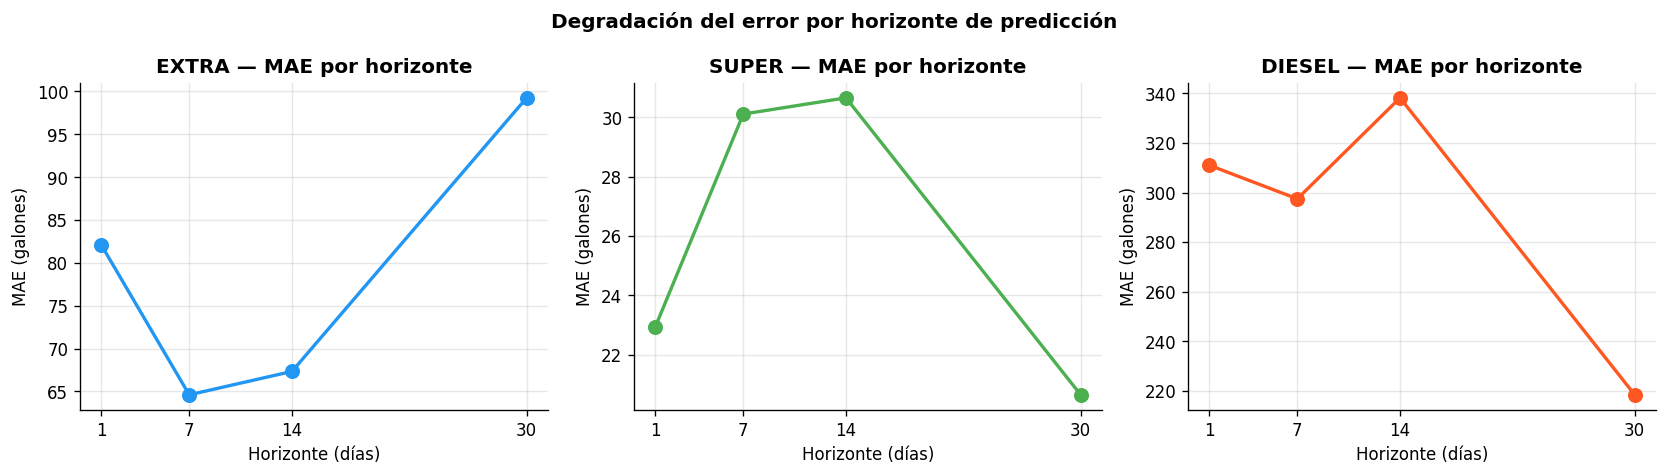

✅ Guardado: c:\Users\javic\Desktop\PUCESA\.Archivos\Test_Semana_9\eda+modelo\Tesis_Combustible\Red Nuronal\Red_Neuronal_Semana_10.4\graficos\predicciones\mae_por_horizonte.png


In [8]:
# ── Evaluar el modelo en test con ventanas de diferentes horizontes ────────
# Estrategia: tomar las predicciones en test y evaluar solo los primeros h días
# de cada ventana de test (simula predicción a h pasos hacia adelante)

HORIZONTES = [1, 7, 14, 30]
filas_horizontes = []

for h in HORIZONTES:
    # Para horizonte h: tomamos los primeros h días del test como si fuera
    # predicción recursive — aproximado usando los residuos acumulados
    # En rigor, evaluamos en bloques de h días del conjunto de test
    row = {'horizonte': h}
    for p in PRODUCTOS:
        y_t = true_test_real[p]
        y_p = pred_test_real[p]
        # Tomar solo múltiplos completos de h
        n_bloques = len(y_t) // h
        if n_bloques == 0:
            row[f'MAE_{p}']  = round(float(mean_absolute_error(y_t, y_p)), 4)
            row[f'RMSE_{p}'] = round(float(np.sqrt(mean_squared_error(y_t, y_p))), 4)
        else:
            # Tomar el último punto de cada bloque como predicción a h pasos
            idx = [(i + 1) * h - 1 for i in range(n_bloques) if (i + 1) * h - 1 < len(y_t)]
            y_t_h = y_t[idx]
            y_p_h = y_p[idx]
            row[f'MAE_{p}']  = round(float(mean_absolute_error(y_t_h, y_p_h)), 4)
            row[f'RMSE_{p}'] = round(float(np.sqrt(mean_squared_error(y_t_h, y_p_h))), 4)
    filas_horizontes.append(row)

df_horizontes = pd.DataFrame(filas_horizontes)

print('\n=== MÉTRICAS POR HORIZONTE ===')
display(df_horizontes)

# Gráfica de degradación de MAE por horizonte
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, p in zip(axes, PRODUCTOS):
    ax.plot(df_horizontes['horizonte'], df_horizontes[f'MAE_{p}'],
            marker='o', color=COLORES[p], linewidth=2, markersize=8)
    ax.set_title(f'{p.upper()} — MAE por horizonte', fontweight='bold')
    ax.set_xlabel('Horizonte (días)')
    ax.set_ylabel('MAE (galones)')
    ax.set_xticks(HORIZONTES)
plt.suptitle('Degradación del error por horizonte de predicción', fontsize=12, fontweight='bold')
plt.tight_layout()
ruta_h = os.path.join(PATHS['graf_pred'], 'mae_por_horizonte.png')
plt.savefig(ruta_h, bbox_inches='tight', dpi=120)
plt.show()
print(f'✅ Guardado: {ruta_h}')

## 8. Gráficas de predicciones futuras <a id='8'></a>

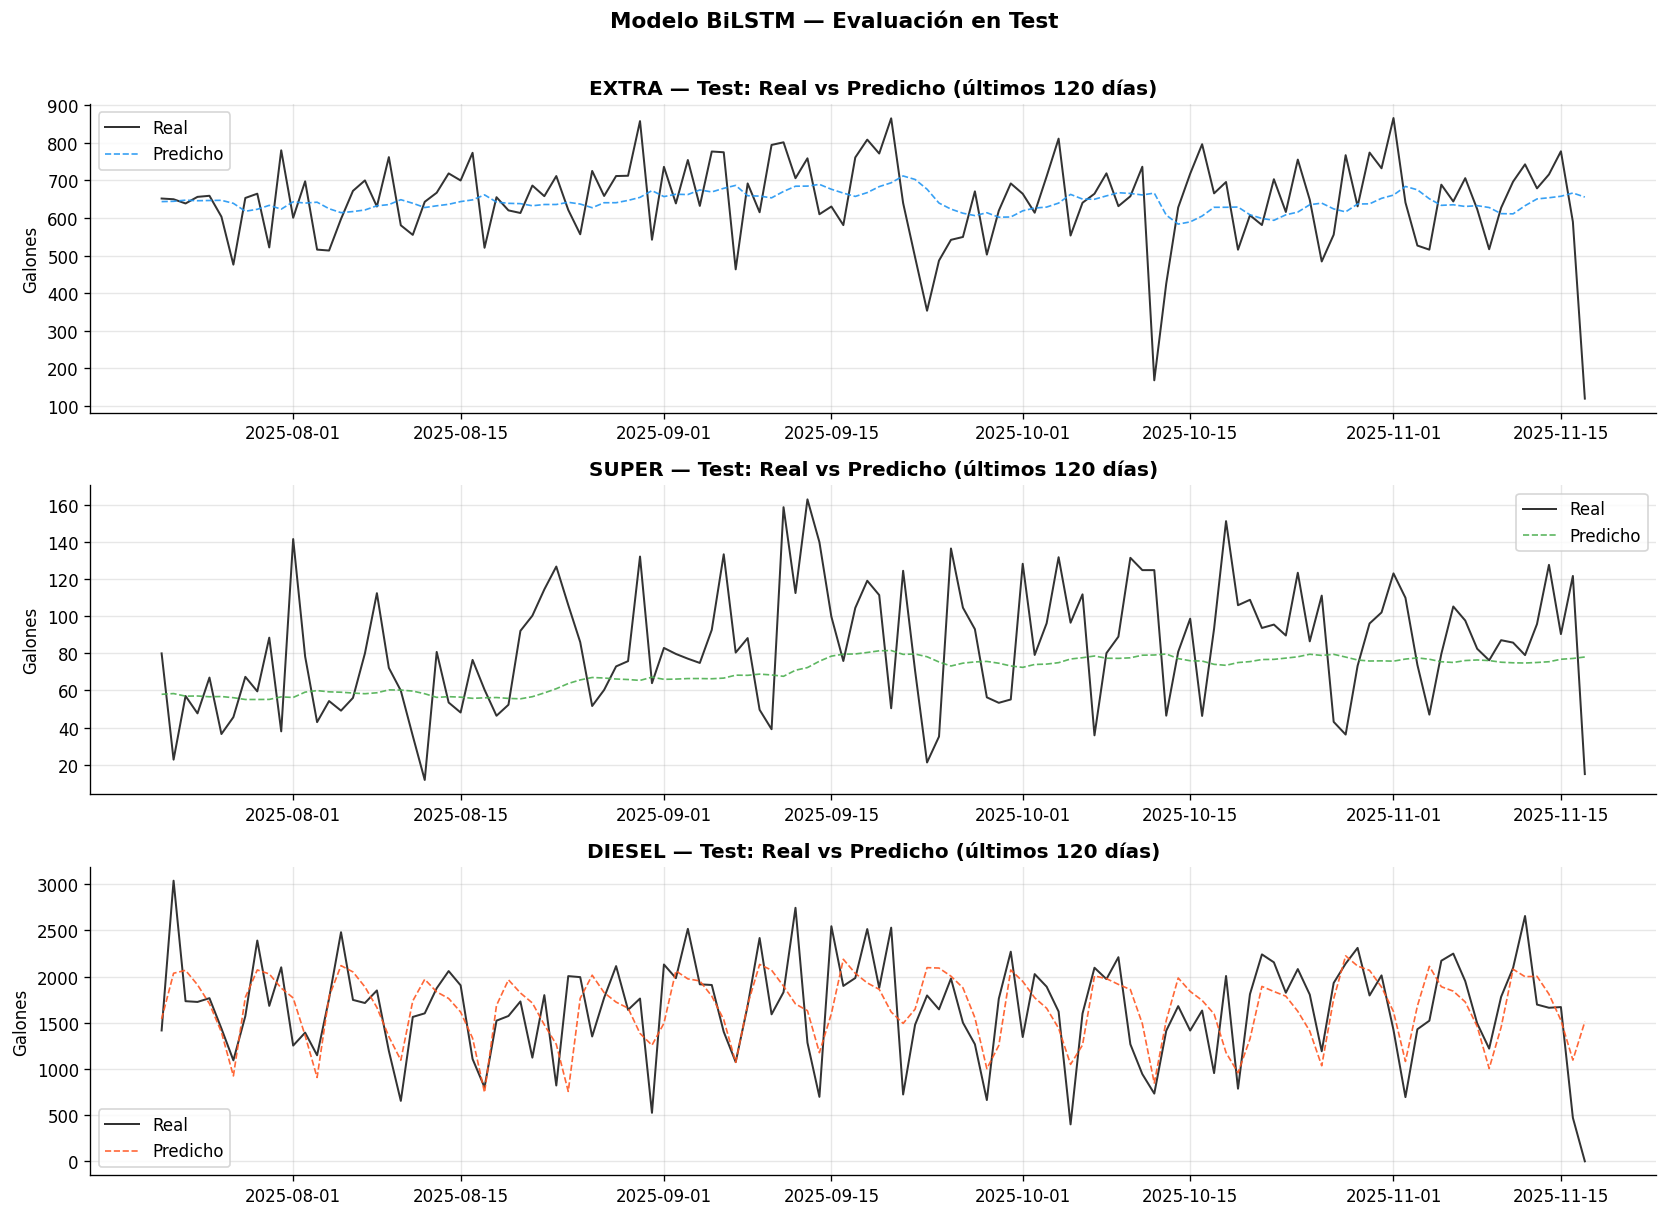

✅ Guardado: c:\Users\javic\Desktop\PUCESA\.Archivos\Test_Semana_9\eda+modelo\Tesis_Combustible\Red Nuronal\Red_Neuronal_Semana_10.4\graficos\predicciones\test_real_vs_pred.png


In [9]:
# ── Gráfica 1: Test real vs predicho ─────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
n_show = min(120, n_comun)  # mostrar los últimos 120 días de test

for ax, p in zip(axes, PRODUCTOS):
    real  = df_pred_test[f'{p}_real'].values[-n_show:]
    pred  = df_pred_test[f'{p}_pred'].values[-n_show:]
    fecha = df_pred_test['fecha'].values[-n_show:]
    ax.plot(fecha, real, label='Real', color='#333333', linewidth=1.2)
    ax.plot(fecha, pred, label='Predicho', color=COLORES[p], linewidth=1.0, alpha=0.9, linestyle='--')
    ax.set_title(f'{p.upper()} — Test: Real vs Predicho (últimos {n_show} días)', fontweight='bold')
    ax.set_ylabel('Galones')
    ax.legend()

plt.suptitle(f'Modelo {MODELO_GANADOR} — Evaluación en Test', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
ruta_g1 = os.path.join(PATHS['graf_pred'], 'test_real_vs_pred.png')
plt.savefig(ruta_g1, bbox_inches='tight', dpi=120)
plt.show()
print(f'✅ Guardado: {ruta_g1}')

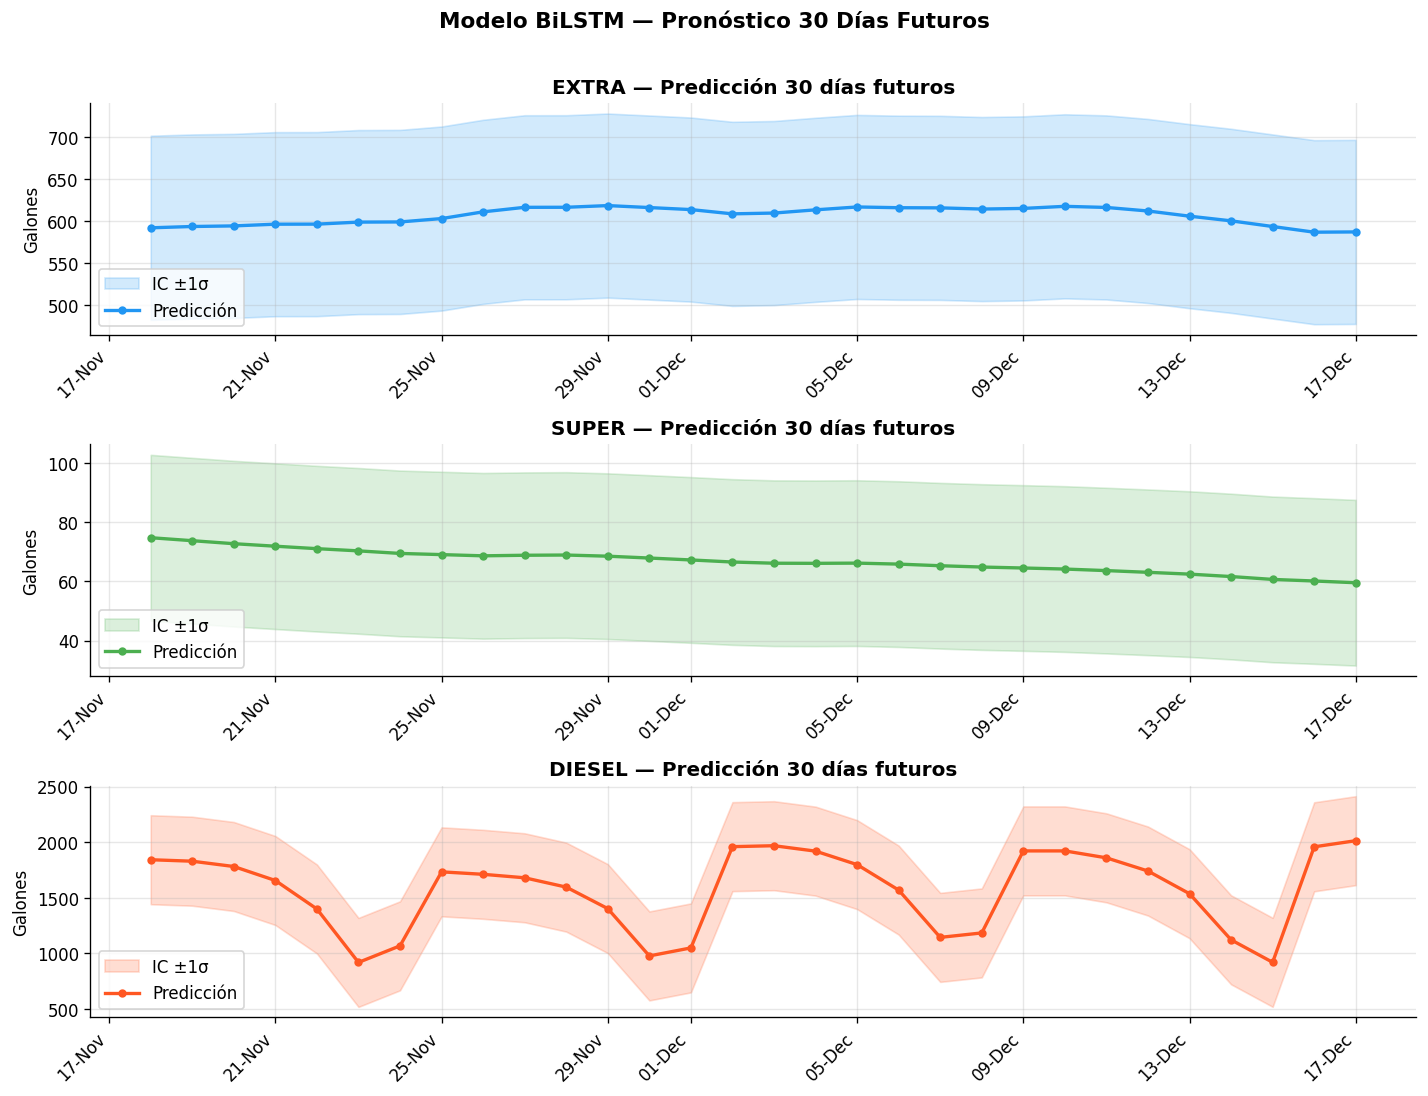

✅ Guardado: c:\Users\javic\Desktop\PUCESA\.Archivos\Test_Semana_9\eda+modelo\Tesis_Combustible\Red Nuronal\Red_Neuronal_Semana_10.4\graficos\predicciones\predicciones_30_dias.png


In [10]:
# ── Gráfica 2: Predicciones futuras 30 días con intervalos ───────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

for ax, p in zip(axes, PRODUCTOS):
    pred  = df_pred_30_ci[f'{p}_pred'].values
    lower = df_pred_30_ci[f'{p}_lower'].values
    upper = df_pred_30_ci[f'{p}_upper'].values
    fechas = df_pred_30_ci['fecha'].values

    ax.fill_between(fechas, lower, upper, alpha=0.2, color=COLORES[p], label='IC ±1σ')
    ax.plot(fechas, pred, color=COLORES[p], linewidth=2, marker='o', markersize=4, label='Predicción')
    ax.set_title(f'{p.upper()} — Predicción 30 días futuros', fontweight='bold')
    ax.set_ylabel('Galones')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle(f'Modelo {MODELO_GANADOR} — Pronóstico 30 Días Futuros', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
ruta_g2 = os.path.join(PATHS['graf_pred'], 'predicciones_30_dias.png')
plt.savefig(ruta_g2, bbox_inches='tight', dpi=120)
plt.show()
print(f'✅ Guardado: {ruta_g2}')

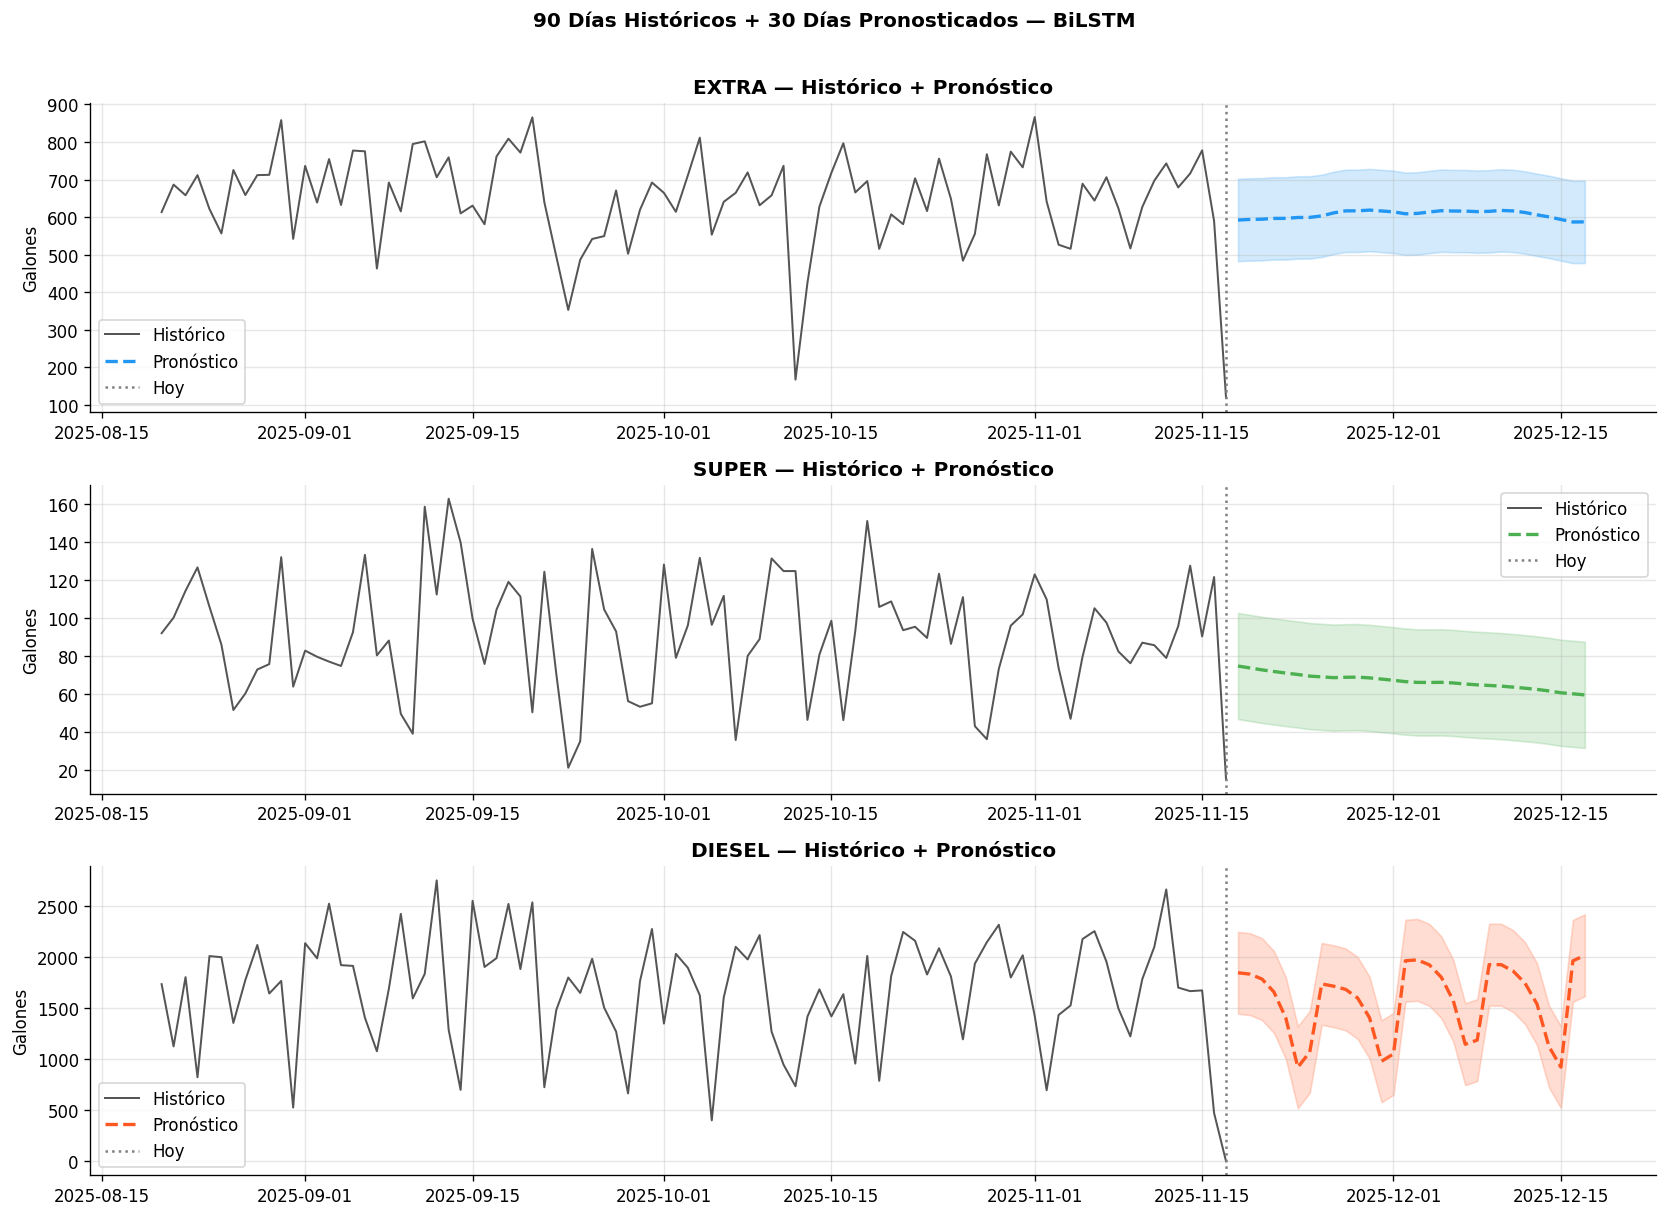

✅ Guardado: c:\Users\javic\Desktop\PUCESA\.Archivos\Test_Semana_9\eda+modelo\Tesis_Combustible\Red Nuronal\Red_Neuronal_Semana_10.4\graficos\predicciones\historico_mas_prediccion.png


In [11]:
# ── Gráfica 3: Contexto histórico + predicciones ──────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
n_hist = 90  # últimos 90 días históricos

for ax, p in zip(axes, PRODUCTOS):
    hist_fechas = df_limpio['fecha'].values[-n_hist:]
    hist_vals   = df_limpio[p].values[-n_hist:]
    pred_fechas = df_pred_30_ci['fecha'].values
    pred_vals   = df_pred_30_ci[f'{p}_pred'].values
    lower       = df_pred_30_ci[f'{p}_lower'].values
    upper       = df_pred_30_ci[f'{p}_upper'].values

    ax.plot(hist_fechas, hist_vals, color='#555555', linewidth=1.2, label='Histórico')
    ax.fill_between(pred_fechas, lower, upper, alpha=0.2, color=COLORES[p])
    ax.plot(pred_fechas, pred_vals, color=COLORES[p], linewidth=2, linestyle='--', label='Pronóstico')
    ax.axvline(x=df_limpio['fecha'].iloc[-1], color='gray', linestyle=':', linewidth=1.5, label='Hoy')
    ax.set_title(f'{p.upper()} — Histórico + Pronóstico', fontweight='bold')
    ax.set_ylabel('Galones')
    ax.legend()

plt.suptitle(f'{n_hist} Días Históricos + 30 Días Pronosticados — {MODELO_GANADOR}',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
ruta_g3 = os.path.join(PATHS['graf_pred'], 'historico_mas_prediccion.png')
plt.savefig(ruta_g3, bbox_inches='tight', dpi=120)
plt.show()
print(f'✅ Guardado: {ruta_g3}')

## 9. Guardado de todos los CSV <a id='9'></a>

In [12]:
# ── Guardar todos los CSV de predicciones ─────────────────────────────────

# 1. predicciones_test_diarias.csv
df_pred_test.to_csv(
    os.path.join(PATHS['data'], 'predicciones_test_diarias.csv'), index=False
)
print(f'✅ predicciones_test_diarias.csv      — {len(df_pred_test)} filas')

# 2. predicciones_diarias.csv (30 días sin intervalos)
df_pred_30.to_csv(
    os.path.join(PATHS['data'], 'predicciones_diarias.csv'), index=False
)
print(f'✅ predicciones_diarias.csv           — {len(df_pred_30)} filas')

# 3. predicciones_diarias_30_dias.csv (con intervalos ±1std)
df_pred_30_ci.to_csv(
    os.path.join(PATHS['data'], 'predicciones_diarias_30_dias.csv'), index=False
)
print(f'✅ predicciones_diarias_30_dias.csv   — {len(df_pred_30_ci)} filas')

# 4. predicciones_semanales.csv
df_pred_semanales.to_csv(
    os.path.join(PATHS['data'], 'predicciones_semanales.csv'), index=False
)
print(f'✅ predicciones_semanales.csv         — {len(df_pred_semanales)} filas')

# 5. predicciones_mensuales.csv
df_pred_mensuales.to_csv(
    os.path.join(PATHS['data'], 'predicciones_mensuales.csv'), index=False
)
print(f'✅ predicciones_mensuales.csv         — {len(df_pred_mensuales)} filas')

# 6. predicciones_anuales.csv
df_pred_anuales.to_csv(
    os.path.join(PATHS['data'], 'predicciones_anuales.csv'), index=False
)
print(f'✅ predicciones_anuales.csv           — {len(df_pred_anuales)} filas')

# 7. resumen_predicciones_horizontes.csv
df_horizontes.to_csv(
    os.path.join(PATHS['data'], 'resumen_predicciones_horizontes.csv'), index=False
)
print(f'✅ resumen_predicciones_horizontes.csv— {len(df_horizontes)} filas')

print('\n✅ TODOS LOS CSV DE PREDICCIONES GUARDADOS')

✅ predicciones_test_diarias.csv      — 206 filas
✅ predicciones_diarias.csv           — 30 filas
✅ predicciones_diarias_30_dias.csv   — 30 filas
✅ predicciones_semanales.csv         — 5 filas
✅ predicciones_mensuales.csv         — 2 filas
✅ predicciones_anuales.csv           — 2 filas
✅ resumen_predicciones_horizontes.csv— 4 filas

✅ TODOS LOS CSV DE PREDICCIONES GUARDADOS


In [13]:
# ── Tabla resumen de predicciones (para el documento de tesis) ────────────
print('\n=== RESUMEN PREDICCIONES 30 DÍAS FUTUROS ===')
display(df_pred_30_ci)

print('\n=== TOTALES PROYECTADOS ===')
for p in PRODUCTOS:
    total = df_pred_30[f'{p}_pred'].sum()
    diario_prom = df_pred_30[f'{p}_pred'].mean()
    print(f'  {p.upper():8s}: total 30 días = {total:>10,.1f} galones  '
          f'(promedio diario: {diario_prom:,.1f})')


=== RESUMEN PREDICCIONES 30 DÍAS FUTUROS ===


,fecha,extra_pred,extra_lower,extra_upper,super_pred,super_lower,super_upper,diesel_pred,diesel_lower,diesel_upper
0,2025-11-18,592.2500,482.6899,701.8101,74.7641,46.7921,102.7361,1842.6902,1442.5120,2242.8684
1,2025-11-19,593.8100,484.2499,703.3701,73.7576,45.7856,101.7296,1829.4754,1429.2972,2229.6536
2,2025-11-20,594.5118,484.9517,704.0719,72.7463,44.7743,100.7183,1781.7783,1381.6001,2181.9565
3,2025-11-21,596.5541,486.9940,706.1142,71.8957,43.9237,99.8677,1655.8659,1255.6878,2056.0441
4,2025-11-22,596.6243,487.0642,706.1844,71.0648,43.0928,99.0368,1399.7567,999.5786,1799.9349
5,2025-11-23,599.0408,489.4807,708.6009,70.3209,42.3489,98.2928,919.3295,519.1513,1319.5077
6,2025-11-24,599.2304,489.6703,708.7905,69.4569,41.4849,97.4289,1068.4324,668.2542,1468.6106
7,2025-11-25,603.2500,493.6899,712.8101,69.0599,41.0879,97.0319,1733.7600,1333.5818,2133.9382
8,2025-11-26,611.2472,501.6871,720.8073,68.6483,40.6763,96.6203,1711.6108,1311.4326,2111.7890
9,2025-11-27,616.6410,507.0809,726.2011,68.8411,40.8691,96.8131,1680.3325,1280.1543,2080.5107



=== TOTALES PROYECTADOS ===
  EXTRA   : total 30 días =   18,201.6 galones  (promedio diario: 606.7)
  SUPER   : total 30 días =    2,004.2 galones  (promedio diario: 66.8)
  DIESEL  : total 30 días =   47,194.1 galones  (promedio diario: 1,573.1)


## 10. Verificación final <a id='10'></a>

In [14]:
print('=' * 65)
print('  VERIFICACIÓN FINAL — NOTEBOOK 05')
print('=' * 65)

archivos_esperados = [
    'predicciones_test_diarias.csv',
    'predicciones_diarias.csv',
    'predicciones_diarias_30_dias.csv',
    'predicciones_semanales.csv',
    'predicciones_mensuales.csv',
    'predicciones_anuales.csv',
    'resumen_predicciones_horizontes.csv',
]

todos_ok = True
for f in archivos_esperados:
    ruta = os.path.join(PATHS['data'], f)
    if os.path.exists(ruta):
        n = len(pd.read_csv(ruta))
        print(f'  ✅ {f:<50} {n} filas')
    else:
        print(f'  ❌ {f:<50} NO ENCONTRADO')
        todos_ok = False

print('\nGráficas generadas en /graficos/predicciones/:')
for g in ['test_real_vs_pred.png', 'predicciones_30_dias.png',
           'historico_mas_prediccion.png', 'mae_por_horizonte.png']:
    ruta = os.path.join(PATHS['graf_pred'], g)
    existe = os.path.exists(ruta)
    print(f'  {"✅" if existe else "❌"} {g}')
    if not existe: todos_ok = False

print('\n' + '=' * 65)
if todos_ok:
    print('  ✅ PIPELINE COMPLETO — TODOS LOS ARCHIVOS GENERADOS')
else:
    print('  ❌ FALTAN ARCHIVOS — REVISAR CELDAS ANTERIORES')
print(f'  Modelo ganador: {MODELO_GANADOR}')
print(f'  Pronóstico: {fechas_futuras_30[0].date()} → {fechas_futuras_30[-1].date()}')
print('=' * 65)
print('\n🎓 Pipeline finalizado — ¡Listo para incluir en la tesis!')

  VERIFICACIÓN FINAL — NOTEBOOK 05
  ✅ predicciones_test_diarias.csv                      206 filas
  ✅ predicciones_diarias.csv                           30 filas
  ✅ predicciones_diarias_30_dias.csv                   30 filas
  ✅ predicciones_semanales.csv                         5 filas
  ✅ predicciones_mensuales.csv                         2 filas
  ✅ predicciones_anuales.csv                           2 filas
  ✅ resumen_predicciones_horizontes.csv                4 filas

Gráficas generadas en /graficos/predicciones/:
  ✅ test_real_vs_pred.png
  ✅ predicciones_30_dias.png
  ✅ historico_mas_prediccion.png
  ✅ mae_por_horizonte.png

  ✅ PIPELINE COMPLETO — TODOS LOS ARCHIVOS GENERADOS
  Modelo ganador: BiLSTM
  Pronóstico: 2025-11-18 → 2025-12-17

🎓 Pipeline finalizado — ¡Listo para incluir en la tesis!
